# Task 1: Data Cleaning & Preprocessing

**Objective:**  
Prepare the raw dataset for analysis by cleaning and standardising the data.

**Tools:**  
Python, pandas

---

## Steps:

1. **Load the dataset** using pandas.
2. **Handle missing values**:
   - Identify missing values in columns.
   - Drop rows or impute missing values if necessary.
3. **Remove duplicate rows** to prevent repeated records.
4. **Standardize data formats**:
   - Convert date columns to `datetime`.
   - Ensure numeric columns are numeric (`float` or `int`).
   - Standardise categorical columns (e.g., stock symbols) to uppercase/stripped text.
5. **Confirm cleaning**:
   - Check data types.
   - Check missing values.
   - Verify no duplicates remain.

> **Tip:** A clean dataset ensures all future analysis is accurate and reliable.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Stock_Prices_Dataset.csv")

In [3]:
print(df.head())

  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391


In [4]:
print(df)

       symbol        date      open      high       low     close    volume
0         AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1        AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2         AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3        ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4         ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391
...       ...         ...       ...       ...       ...       ...       ...
497467    XYL  2017-12-29   68.5300   68.8000   67.9200   68.2000   1046677
497468    YUM  2017-12-29   82.6400   82.7100   81.5900   81.6100   1347613
497469    ZBH  2017-12-29  121.7500  121.9500  120.6200  120.6700   1023624
497470   ZION  2017-12-29   51.2800   51.5500   50.8100   50.8300   1261916
497471    ZTS  2017-12-29   72.5500   72.7600   72.0400   72.0400   1704122

[497472 rows x 7 columns]


In [5]:
print(df.columns)

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB
None


In [7]:
print(df.isnull().sum())

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [8]:
print(df.dtypes)

symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object


In [9]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [10]:
print(df["date"].dtypes)

datetime64[ns]


In [11]:
print(df.isnull().sum())

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [12]:
df = df.dropna()

In [13]:
print(df.isnull().sum())

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [14]:
df = df.drop_duplicates()

In [15]:
print("Remaining rows:", df.shape[0])

Remaining rows: 497461


In [16]:
df["symbol"] = df["symbol"].str.upper().str.strip()

In [17]:
print(df["symbol"].head())

0     AAL
1    AAPL
2     AAP
3    ABBV
4     ABC
Name: symbol, dtype: object


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 497461 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497461 non-null  object        
 1   date    497461 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497461 non-null  float64       
 4   low     497461 non-null  float64       
 5   close   497461 non-null  float64       
 6   volume  497461 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 30.4+ MB
None


In [19]:
print(df.isnull().sum())

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [20]:
print(df.duplicated().sum())

0


# Task 2: Exploratory Data Analysis (EDA)

**Objective:**  
Explore the cleaned dataset to understand distributions, trends, and relationships between variables.

**Tools:**  
Python, pandas, matplotlib, seaborn, numpy

---

## Steps:

1. **Summary Statistics**
   - Calculate mean, median, mode, and standard deviation for numeric columns.
2. **Data Distribution**
   - Visualise numeric features using histograms.
   - Identify outliers with boxplots.
3. **Relationships between variables**
   - Use scatter plots to observe correlations between features (e.g., open vs close prices).
   - Generate a correlation heatmap to identify strong relationships between numeric columns.

> **Tip:** EDA provides insight into the dataset, helping you make informed decisions for further analysis.

In [21]:
import pandas as pd

In [22]:
import numpy as np

In [23]:
import matplotlib.pyplot as plt

In [24]:
import seaborn as sns

In [25]:
%matplotlib inline

In [26]:
print("=== Summary Statistics ===\n")

=== Summary Statistics ===



In [27]:
numeric_cols = ["open", "high", "low", "close", "volume"]

df.mean() → average price/volume

df.median() → middle value

df.mode() → most frequent value

df.std() → standard deviation

In [28]:
print("Mean:\n", df[numeric_cols].mean(), "\n")

Mean:
 open      8.635227e+01
high      8.713272e+01
low       8.555262e+01
close     8.636859e+01
volume    4.253695e+06
dtype: float64 



In [29]:
print("Median:\n", df[numeric_cols].median(), "\n")

Median:
 open      6.497000e+01
high      6.556000e+01
low       6.435740e+01
close     6.498000e+01
volume    2.085013e+06
dtype: float64 



In [30]:
print("Mode:\n", df[numeric_cols].mode().iloc[0], "\n")

Mode:
 open           70.0
high           72.0
low            77.0
close          34.5
volume    1241019.0
Name: 0, dtype: float64 



In [31]:
print("Standard Deviation:\n", df[numeric_cols].std(), "\n")

Standard Deviation:
 open      1.014712e+02
high      1.023123e+02
low       1.005712e+02
close     1.014715e+02
volume    8.232210e+06
dtype: float64 



In [32]:
print("=== Histograms ===")

=== Histograms ===


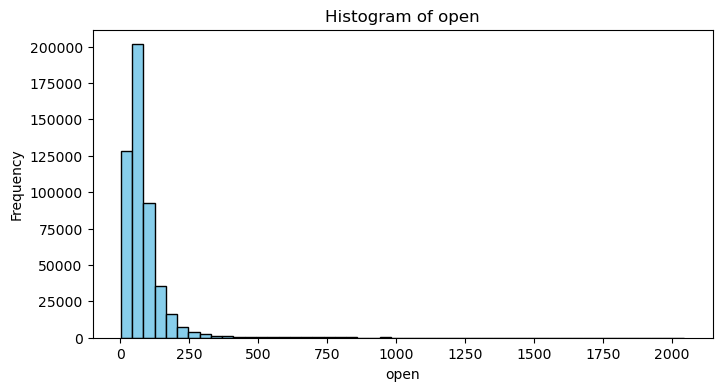

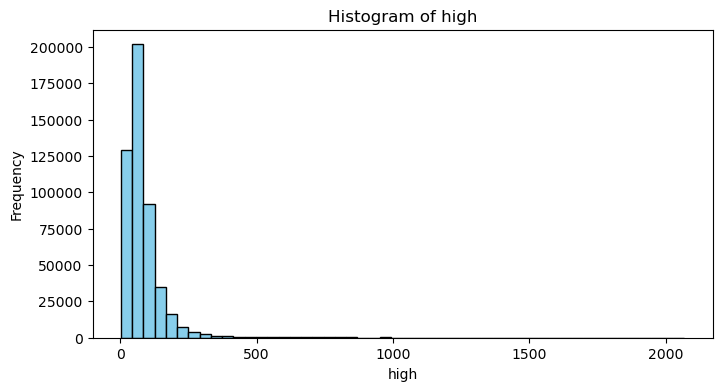

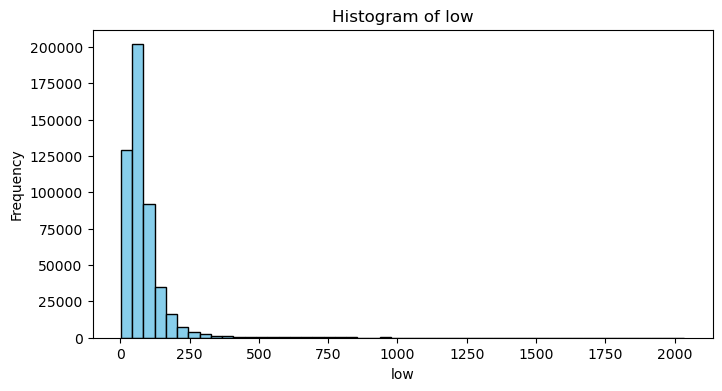

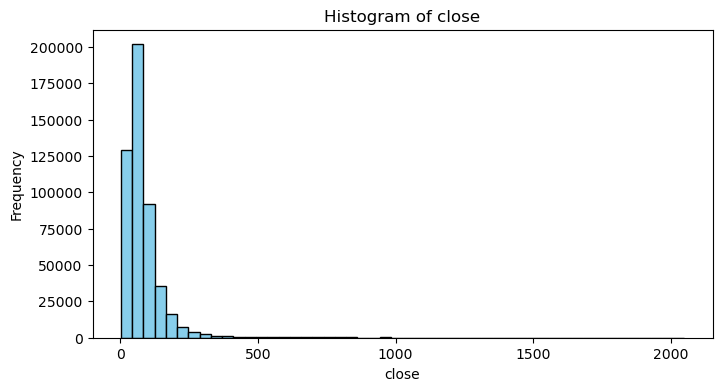

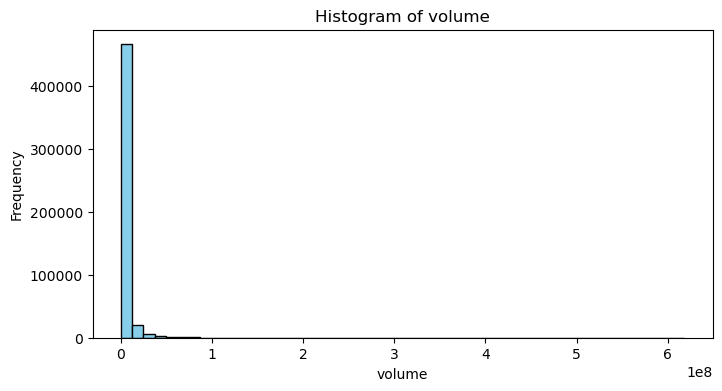

In [33]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=50, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [34]:
print("=== Boxplots ===")

=== Boxplots ===


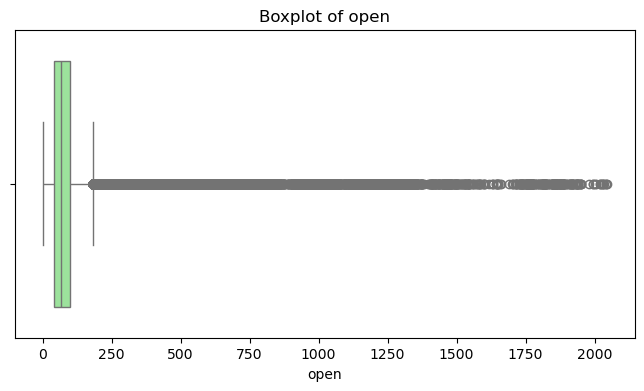

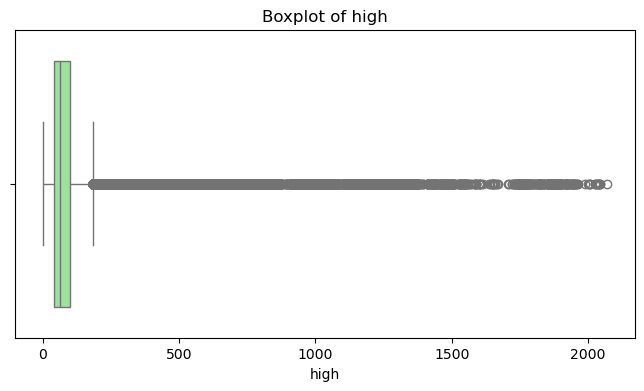

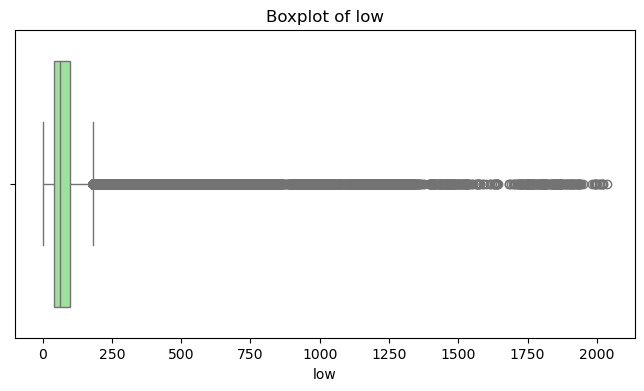

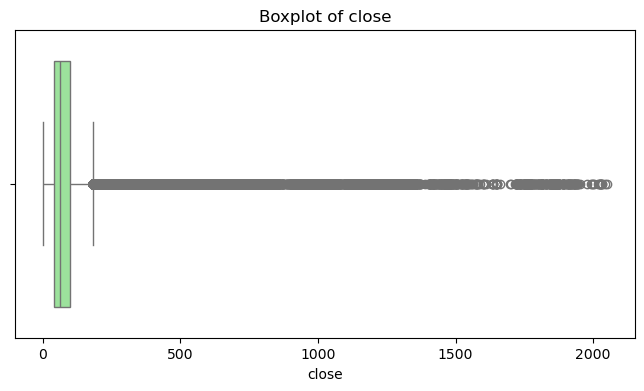

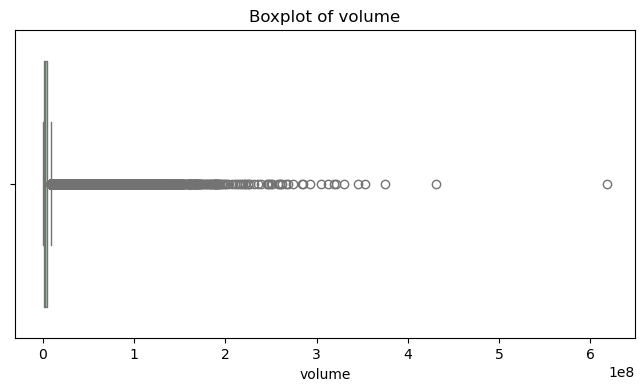

In [35]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.show()

In [36]:
print("=== Scatter Plot: Open vs Close ===")

=== Scatter Plot: Open vs Close ===


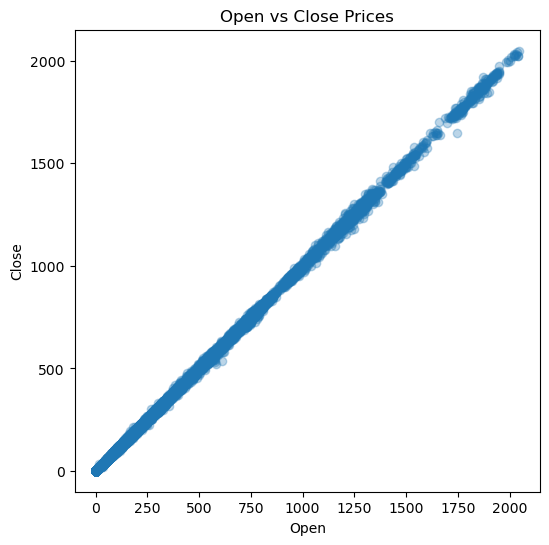

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(df['open'], df['close'], alpha=0.3)
plt.title('Open vs Close Prices')
plt.xlabel('Open')
plt.ylabel('Close')
plt.show()

In [38]:
print("=== Correlation Heatmap ===")

=== Correlation Heatmap ===


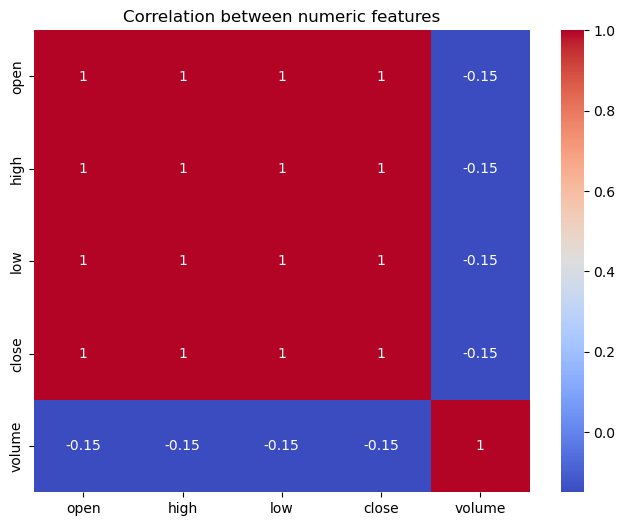

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between numeric features')
plt.show()

# Task 3: Basic Data Visualization

**Objective:**  
Transform your clean dataset into visual insights using bar plots, line charts, and scatter plots. Customize charts with titles, labels, and legends, and export images for reporting purposes.

**Tools:**  
Python, matplotlib, seaborn

---

## Steps:

1. **Bar Plots**  
   - Visualize aggregated metrics, e.g., total trading volume per stock.  
   - Identify top-performing or most active stocks.  

2. **Line Charts**  
   - Plot trends over time, e.g., closing price of a stock.  
   - Highlight patterns, seasonality, or overall growth.  

3. **Scatter Plots**  
   - Explore relationships between numerical features, e.g., open vs close prices.  
   - Add extra dimensions using color (`hue`) and size (`volume`).  

4. **Customizations**  
   - Add **titles, axis labels, legends**.  
   - Rotate x-axis labels for readability.  
   - Use color palettes for clarity and visual appeal.  

5. **Exporting Plots**  
   - Save plots as images using `plt.savefig("filename.png")` for reports.  

---

> **Tip:** Keep your plots clean, readable, and labeled — this is exactly what analysts do when sharing results with managers or clients.

In [40]:
import matplotlib.pyplot as plt

In [41]:
import seaborn as sns

In [42]:
top_volume = df.groupby('symbol')['volume'].sum().sort_values(ascending=False).head(10)

C:\Users\akins\AppData\Local\Temp\ipykernel_7836\4282637841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_volume.index, y=top_volume.values, palette="viridis")


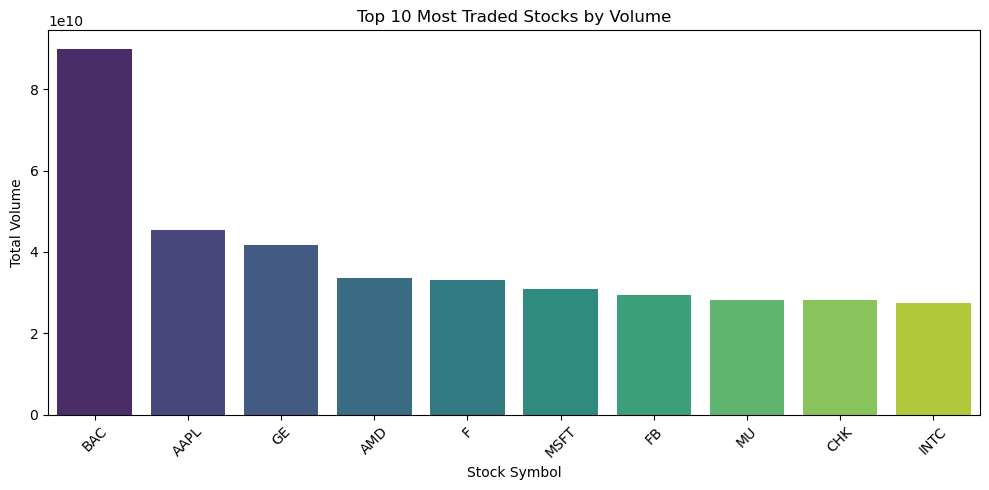

In [43]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_volume.index, y=top_volume.values, palette="viridis")
plt.title("Top 10 Most Traded Stocks by Volume")
plt.xlabel("Stock Symbol")
plt.ylabel("Total Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
plt.savefig("top10_traded_stocks.png")

<Figure size 640x480 with 0 Axes>

In [45]:
df_aapl = df[df['symbol'] == 'AAPL'].sort_values('date')

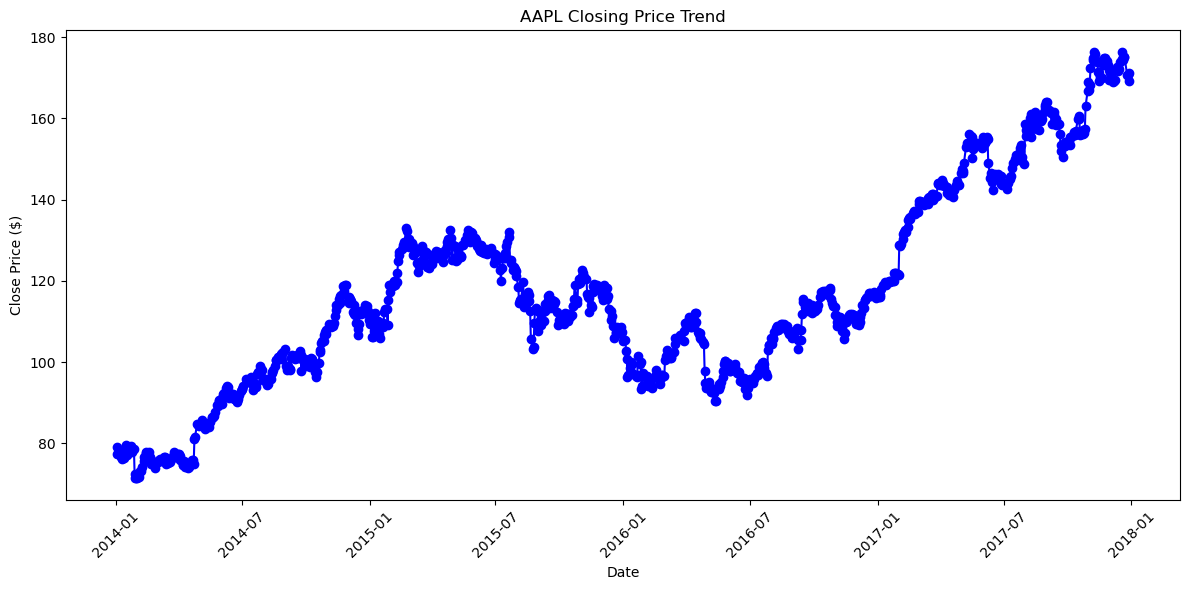

In [46]:
plt.figure(figsize=(12,6))
plt.plot(df_aapl['date'], df_aapl['close'], marker='o', linestyle='-', color='blue')
plt.title("AAPL Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
plt.savefig("AAPL_closing_price.png")

<Figure size 640x480 with 0 Axes>

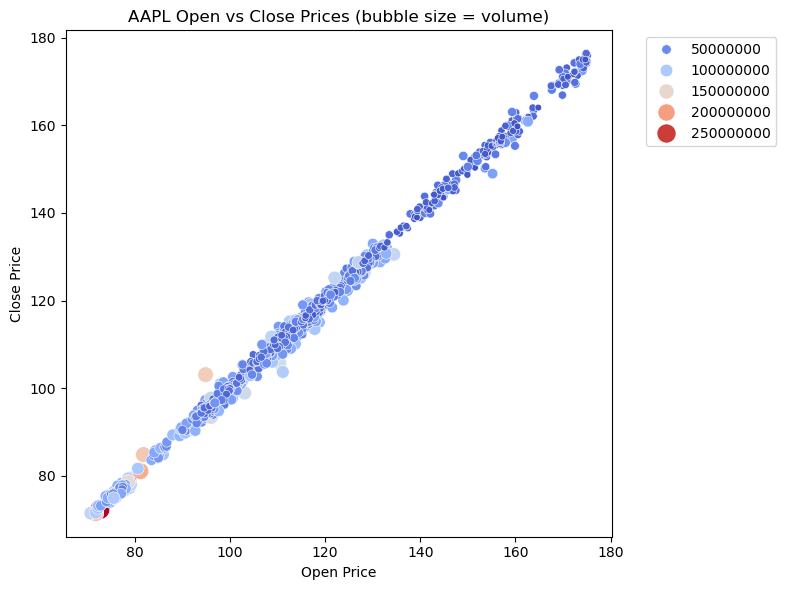

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_aapl, x='open', y='close', hue='volume', size='volume', palette='coolwarm', sizes=(20,200))
plt.title("AAPL Open vs Close Prices (bubble size = volume)")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)  # Legend outside the plot
plt.tight_layout()
plt.show()

In [49]:
plt.savefig("AAPL_scatter.png")

<Figure size 640x480 with 0 Axes>

# Level 2: Regression Analysis

## Objective
Perform a simple linear regression analysis to predict one variable based on another.

## Tools
Python, pandas, scikit-learn

---

## Steps

1. **Prepare the Data**
   - Select relevant variables for prediction.
   - In this analysis, the **open price** will be used to predict the **close price**.

2. **Split the Dataset**
   - Divide the dataset into **training data** and **testing data**.
   - Training data is used to train the model.
   - Testing data is used to evaluate model performance.

3. **Fit a Linear Regression Model**
   - Use `LinearRegression` from scikit-learn to train the model.

4. **Model Evaluation**
   - Evaluate the model using:
     - **R-squared (R²)**: measures how well the model explains the data.
     - **Mean Squared Error (MSE)**: measures prediction error.

5. **Interpret the Model**
   - Examine the **coefficient** (slope) and **intercept** of the regression model.
   - Understand how changes in the independent variable affect the predicted value.

> Linear regression helps identify relationships between variables and allows us to make predictions based on historical data.

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
from sklearn.metrics import mean_squared_error, r2_score

In [53]:
X = df[['open']]

In [54]:
y = df['close']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
model = LinearRegression()

In [57]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
y_pred = model.predict(X_test)

In [59]:
mse = mean_squared_error(y_test, y_pred)

In [60]:
r2 = r2_score(y_test, y_pred)

In [61]:
print("Model Coefficient:", model.coef_[0])

Model Coefficient: 0.9998744981397071


In [62]:
print("Model Intercept:", model.intercept_)

Model Intercept: 0.026677540332443073


In [63]:
print("Mean Squared Error:", mse)

Mean Squared Error: 2.7260823685319755


In [64]:
print("R-squared:", r2)

R-squared: 0.9997383343436389


In [65]:
import matplotlib.pyplot as plt

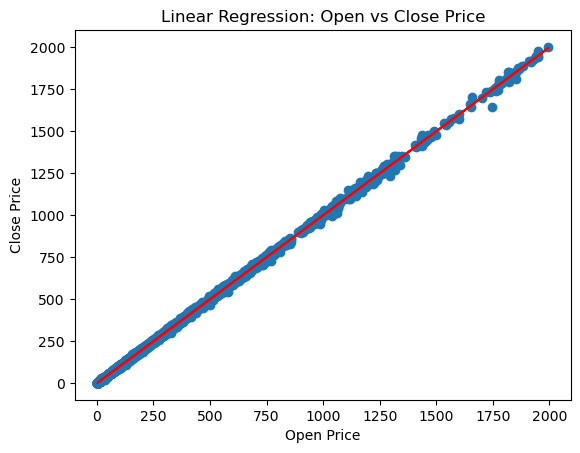

In [66]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.title("Linear Regression: Open vs Close Price")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.show()

# Task 2: Time Series Analysis

## Objective
Analyze time-series data to identify trends, seasonal patterns, and irregular fluctuations in stock prices over time.

## Tools
Python, pandas, matplotlib, statsmodels

---

## Steps

1. **Plot Time-Series Data**
   - Visualize stock prices across time.
   - Identify trends or patterns in the data.

2. **Time Series Decomposition**
   - Decompose the series into three components:
     - **Trend**: long-term movement in the data
     - **Seasonality**: repeating patterns over time
     - **Residuals**: random noise or unexplained variation

3. **Moving Average Smoothing**
   - Apply a moving average to smooth short-term fluctuations.
   - Highlight the long-term trend more clearly.

> Time series analysis helps analysts understand how values change over time and detect patterns useful for forecasting.

In [67]:
import matplotlib.pyplot as plt

In [68]:
df_aapl = df[df["symbol"] == "AAPL"].sort_values("date")

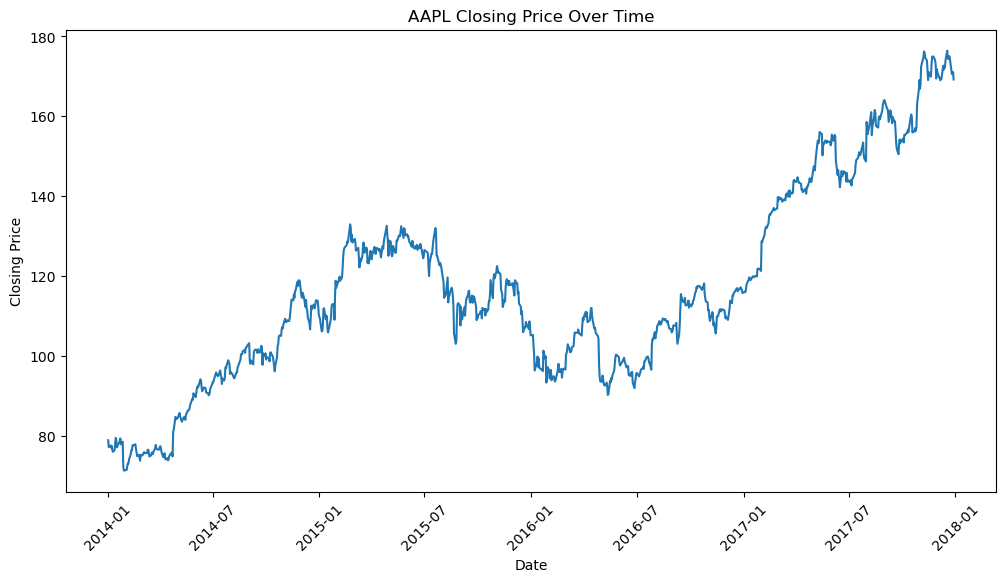

In [69]:
plt.figure(figsize=(12,6))
plt.plot(df_aapl["date"], df_aapl["close"])
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.show()

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [71]:
decomposition = seasonal_decompose(df_aapl["close"], model="additive", period=365)

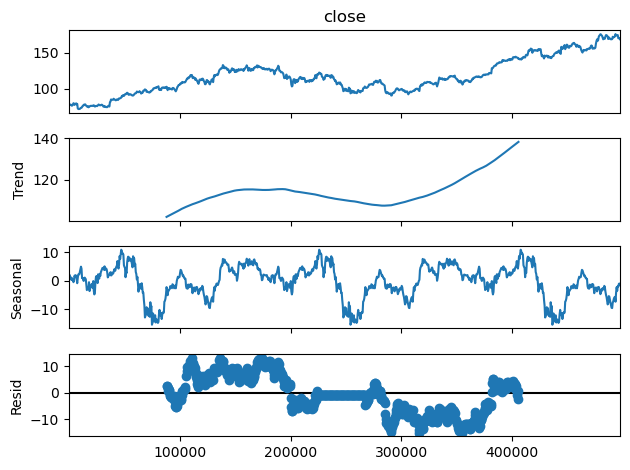

In [72]:
decomposition.plot()
plt.show()

In [73]:
df_aapl["moving_avg_30"] = df_aapl["close"].rolling(window=30).mean()

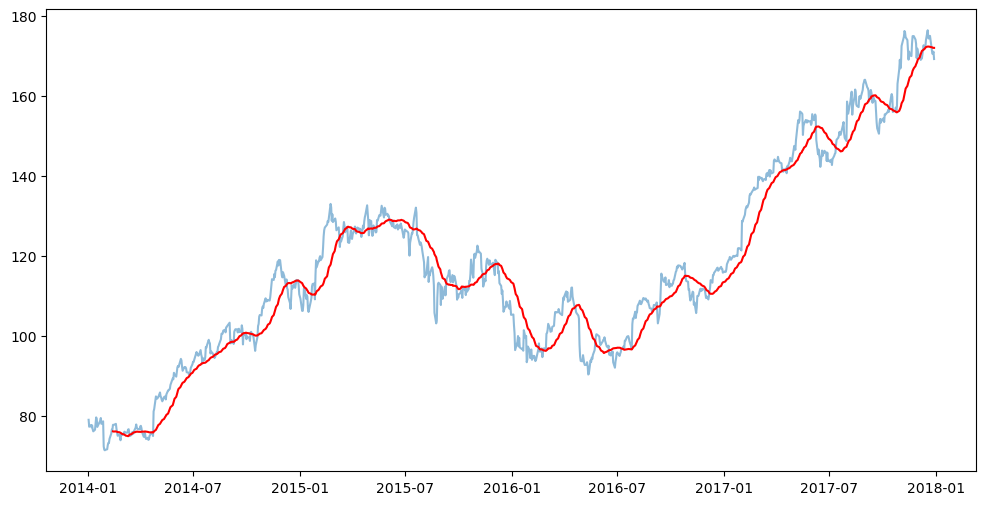

In [74]:
plt.figure(figsize=(12,6))
plt.plot(df_aapl["date"], df_aapl["close"], label="Original Price", alpha=0.5)
plt.plot(df_aapl["date"], df_aapl["moving_avg_30"], label="30-Day Moving Average", color="red")

In [75]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

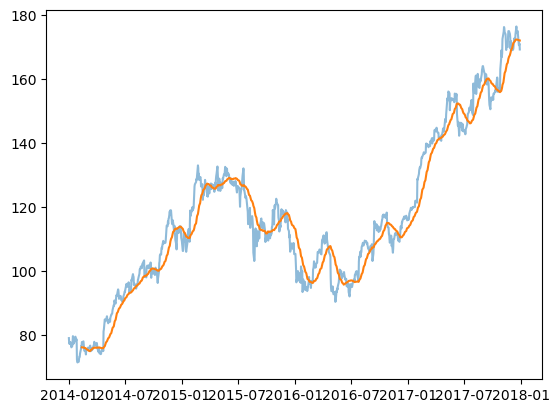

In [76]:
plt.plot(df_aapl["date"], df_aapl["close"], label="Original Price", alpha=0.5)
plt.plot(df_aapl["date"], df_aapl["moving_avg_30"], label="30-Day Moving Average")

Text(0, 0.5, 'Price')

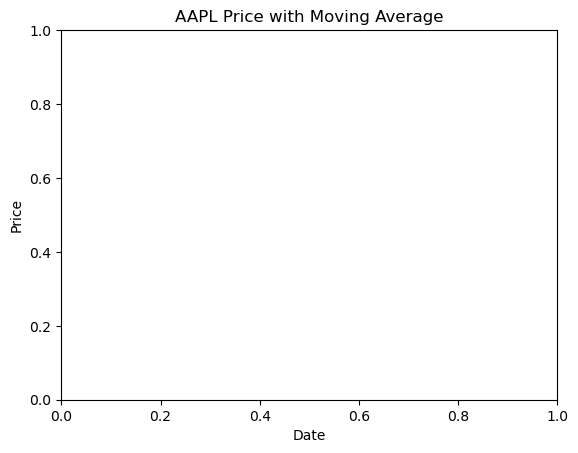

In [77]:
plt.title("AAPL Price with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")

C:\Users\akins\AppData\Local\Temp\ipykernel_7836\4061938096.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


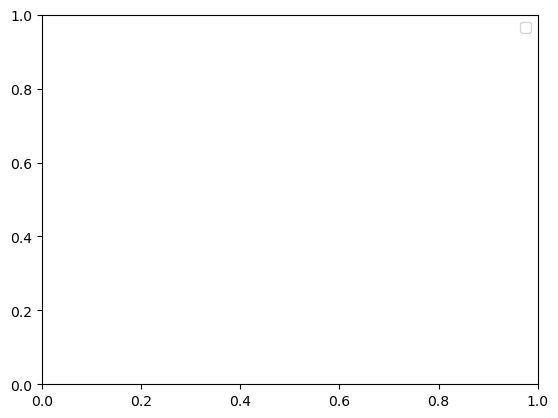

In [78]:
plt.legend()

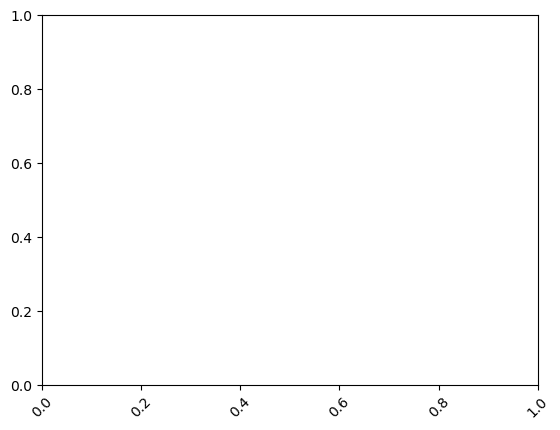

In [79]:
plt.xticks(rotation=45)
plt.show()

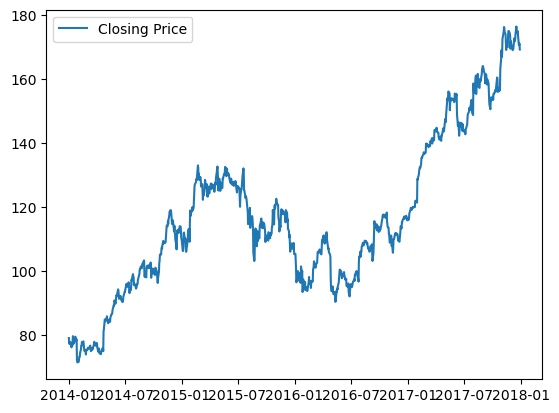

In [80]:
plt.plot(df_aapl["date"], df_aapl["close"], label="Closing Price")
plt.legend()

# Task 3: Clustering Analysis (K-Means)

## Objective
Use K-Means clustering to group similar stocks based on their numerical features.

## Tools
Python, pandas, scikit-learn, matplotlib, seaborn

---

## Steps

1. **Feature Selection**
   - Select relevant numerical variables such as:
     - open
     - high
     - low
     - close
     - volume

2. **Data Standardization**
   - Standardize the dataset using `StandardScaler` so all variables contribute equally to clustering.

3. **Determine Optimal Clusters**
   - Use the **Elbow Method** to identify the best number of clusters (K).

4. **Apply K-Means Clustering**
   - Fit the K-Means model and assign cluster labels to the dataset.

5. **Cluster Visualization**
   - Plot clusters using a 2D scatter plot to observe how data points group together.

> Clustering helps analysts identify patterns and similarities within datasets without predefined labels.

In [81]:
from sklearn.preprocessing import StandardScaler

In [82]:
features = df[['open', 'high', 'low', 'close', 'volume']]

In [83]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [84]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [85]:
inertia = []

In [86]:
K = range(1, 11)

In [87]:
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

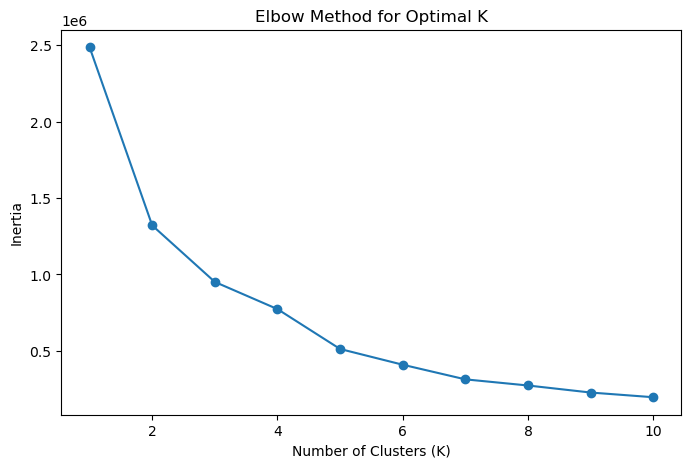

In [88]:
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [89]:
kmeans = KMeans(n_clusters=3, random_state=42)

In [90]:
df['cluster'] = kmeans.fit_predict(scaled_data)

In [91]:
print(df[['open','close','volume','cluster']].head())

       open     close    volume  cluster
0   25.0700   25.3600   8998943        2
1   79.3828   79.0185  58791957        2
2  110.3600  109.7400    542711        2
3   52.1200   51.9800   4569061        2
4   70.1100   69.8900   1148391        2


In [92]:
import seaborn as sns

In [93]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

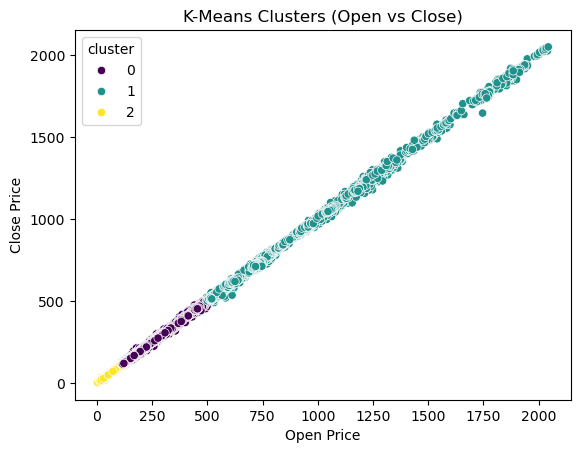

In [94]:
sns.scatterplot(
    x=df['open'],
    y=df['close'],
    hue=df['cluster'],
    palette='viridis'
)

plt.title("K-Means Clusters (Open vs Close)")
plt.xlabel("Open Price")
plt.ylabel("Close Price")

plt.show()

In [95]:
df_sample = df.sample(5000, random_state=42)

# Level 3: Predictive Modeling (Classification)

## Objective
Build classification models to predict whether a stock's closing price will be higher than its opening price.

## Tools
Python, pandas, scikit-learn, matplotlib

---

## Steps

1. **Create Target Variable**
   - Generate a binary column indicating whether the closing price is higher than the opening price.

2. **Preprocess the Data**
   - Select relevant numerical features.
   - Scale features using `StandardScaler`.

3. **Train-Test Split**
   - Divide the dataset into training and testing sets.

4. **Train Multiple Models**
   - Logistic Regression
   - Decision Tree
   - Random Forest

5. **Evaluate Model Performance**
   - Accuracy
   - Precision
   - Recall
   - F1-score

6. **Hyperparameter Tuning**
   - Use GridSearchCV to find the best model parameters.

> Classification models help predict categorical outcomes and support decision-making.

In [96]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [97]:
df.head()

,symbol,date,open,high,low,close,volume,cluster
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,2
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,2
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,2
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,2
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,2


In [98]:
df["price_up"] = (df["close"] > df["open"]).astype(int)

In [99]:
print(df[['open','close','price_up']].head())

       open     close  price_up
0   25.0700   25.3600         1
1   79.3828   79.0185         0
2  110.3600  109.7400         0
3   52.1200   51.9800         0
4   70.1100   69.8900         0


In [100]:
X = df[["open","high","low","volume"]]
y = df["price_up"]

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [102]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [103]:
y_pred = model.predict(X_test)

In [104]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.5158855396862091
              precision    recall  f1-score   support

           0       0.52      0.02      0.05     48272
           1       0.52      0.98      0.68     51221

    accuracy                           0.52     99493
   macro avg       0.52      0.50      0.36     99493
weighted avg       0.52      0.52      0.37     99493



In [105]:
tree = DecisionTreeClassifier()

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, pred_tree))

Decision Tree Accuracy: 0.7581940438020766


In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

# Task 3: Natural Language Processing (NLP) – Sentiment Analysis

## Objective
Analyze text data to determine the sentiment expressed in the text (positive, negative, or neutral).

## Tools
Python, nltk, TextBlob, pandas, matplotlib

---

## Steps

1. **Text Preprocessing**
   - Tokenization (splitting text into words)
   - Removing stopwords (common words like "the", "is")
   - Stemming or lemmatization (reducing words to their base form)

2. **Sentiment Analysis**
   - Use TextBlob or NLTK to determine the polarity of text.

3. **Visualization**
   - Plot sentiment distribution.
   - Generate word clouds to show frequently used words.

> Sentiment analysis helps organizations understand opinions, feedback, and emotions expressed in text data.

In [ ]:
!pip install nltk textblob wordcloud

In [ ]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from textblob import TextBlob
from wordcloud import WordCloud

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')

In [ ]:
data = {
    "text": [
        "The stock market is performing extremely well today",
        "I am disappointed with the company's earnings report",
        "The product quality is excellent and I love it",
        "Customer service was terrible and frustrating",
        "The new update is amazing and works perfectly",
        "The experience was bad and not worth the price"
    ]
}

df_text = pd.DataFrame(data)

print(df_text)

In [ ]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess(text):
    
    words = word_tokenize(text.lower())
    
    filtered_words = [
        stemmer.stem(word)
        for word in words
        if word.isalpha() and word not in stop_words
    ]
    
    return " ".join(filtered_words)

df_text["clean_text"] = df_text["text"].apply(preprocess)

print(df_text)

In [ ]:
def get_sentiment(text):
    
    polarity = TextBlob(text).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df_text["sentiment"] = df_text["clean_text"].apply(get_sentiment)

print(df_text)

In [ ]:
sentiment_counts = df_text["sentiment"].value_counts()

In [ ]:
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar")

In [ ]:
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [ ]:
text_all = " ".join(df_text["clean_text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_all)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Word Cloud of Most Frequent Words")

plt.show()